ErrorL2 = 2.072e-14
Position | FD Potential | Exact Potential
------------------------------------------
   0.000 |       5.0000 |          5.0000
   0.330 |       4.0145 |          4.0145
   0.660 |       2.9441 |          2.9441
   1.005 |       1.7603 |          1.7603
   1.335 |       0.5908 |          0.5908
   1.665 |      -0.5908 |         -0.5908
   1.995 |      -1.7603 |         -1.7603
   2.340 |      -2.9441 |         -2.9441
   2.670 |      -4.0145 |         -4.0145
   3.000 |      -5.0000 |         -5.0000


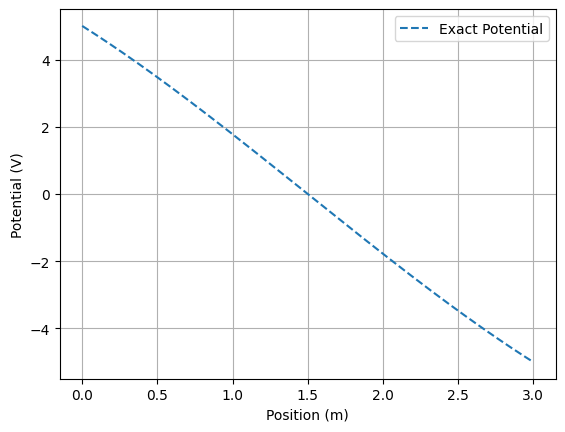

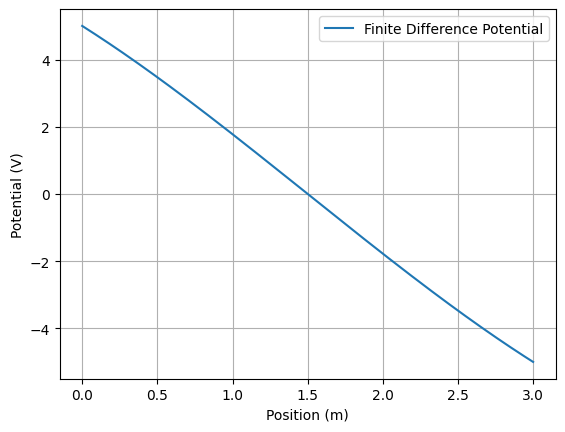

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DomainLength = 3.0
PotentialAtZero = 5.0
PotentialAtEnd = -5.0
GridPoints = 201

def ChargeDensity(x):
    return 1.0 - (2.0/3.0) * x

Positions = np.linspace(0.0, DomainLength, GridPoints)
ConstantC2 = PotentialAtZero
ConstantC1 = (PotentialAtEnd - (-(DomainLength**2)/2 + (DomainLength**3)/9 + PotentialAtZero)) / DomainLength
ExactPotential = -(Positions**2)/2 + (Positions**3)/9 + ConstantC1 * Positions + ConstantC2

StepSize = DomainLength / (GridPoints - 1)
SubDiagonal = np.ones(GridPoints - 1) / StepSize**2
MainDiagonal = -2.0 * np.ones(GridPoints) / StepSize**2
SuperDiagonal = np.ones(GridPoints - 1) / StepSize**2
RightHandSide = -ChargeDensity(Positions)

MainDiagonal[0], SuperDiagonal[0], RightHandSide[0] = 1.0, 0.0, PotentialAtZero
SubDiagonal[-1], MainDiagonal[-1], RightHandSide[-1] = 0.0, 1.0, PotentialAtEnd

for i in range(1, GridPoints):
    Weight = SubDiagonal[i-1] / MainDiagonal[i-1]
    MainDiagonal[i] -= Weight * SuperDiagonal[i-1]
    RightHandSide[i] -= Weight * RightHandSide[i-1]

FiniteDifferencePotential = np.empty(GridPoints)
FiniteDifferencePotential[-1] = RightHandSide[-1] / MainDiagonal[-1]
for i in range(GridPoints - 2, -1, -1):
    FiniteDifferencePotential[i] = (
        RightHandSide[i] - SuperDiagonal[i] * FiniteDifferencePotential[i+1]
    ) / MainDiagonal[i]

ErrorL2 = np.sqrt(np.mean((FiniteDifferencePotential - ExactPotential)**2))
print(f"ErrorL2 = {ErrorL2:.3e}")

SamplePositions = np.linspace(0.0, DomainLength, 10)
print(f"{'Position':>8s} | {'FD Potential':>12s} | {'Exact Potential':>15s}")
print("-" * 42)
for pos in SamplePositions:
    idx = np.argmin(np.abs(Positions - pos))
    print(
        f"{Positions[idx]:8.3f} | "
        f"{FiniteDifferencePotential[idx]:12.4f} | "
        f"{ExactPotential[idx]:15.4f}"
    )

plt.plot(Positions, ExactPotential, '--', label='Exact Potential')
plt.grid(True)
plt.xlabel('Position (m)')
plt.ylabel('Potential (V)')
plt.legend()
plt.show()

plt.plot(Positions, FiniteDifferencePotential, label='Finite Difference Potential')
plt.grid(True)
plt.xlabel('Position (m)')
plt.ylabel('Potential (V)')
plt.legend()
plt.show()
